In [3]:
# GDP Case Study: California Housing
# Phase 0 – Data loading and basic setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Set plotting style for later phases
sns.set(style="whitegrid", context="notebook")

# Load California Housing dataset as a pandas DataFrame
california = fetch_california_housing(as_frame=True)
X = california.data.copy()
y = california.target.copy()  # MedHouseVal

# Combine into a single DataFrame for convenience
df = X.copy()
df["MedHouseVal"] = y

print("Shape of feature matrix X:", X.shape)
print("Shape of target y:", y.shape)
print("Columns in X:", list(X.columns))


Shape of feature matrix X: (20640, 8)
Shape of target y: (20640,)
Columns in X: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Variable definitions (California Housing features)

Based on the dataset documentation (`california.DESCR`):

- `MedInc`: Median income in the block group, in tens of thousands of dollars (e.g. 8.0 ≈ $80,000).
- `HouseAge`: Median house age in the block group, in years.
- `AveRooms`: Average number of rooms per household (total rooms / households).
- `AveBedrms`: Average number of bedrooms per household (total bedrooms / households).
- `Population`: Total population of the block group.
- `AveOccup`: Average household occupancy, computed as population / households (a proxy for crowding).
- `Latitude`: Latitude (in degrees) of the block group centroid.
- `Longitude`: Longitude (in degrees) of the block group centroid.
- `MedHouseVal`: Median house value in the block group, in $100,000s (e.g. 2.0 ≈ $200,000).

In [ ]:
# Inspect the built-in dataset description from scikit-learn

print(california.DESCR[:2000])  # show the first 2000 characters for readability

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:

print("First 5 rows:")
df.head()  


First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# confirm data has loaded correctly with no missing values
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [10]:

# Create a reproducible train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Validation shapes:", X_valid.shape, y_valid.shape)

Train shapes: (16512, 8) (16512,)
Validation shapes: (4128, 8) (4128,)


## Phase 1 – Data Generating Process (DGP) Hypothesis

In this case study, the target variable `MedHouseVal` (median house value in a census tract) is continuous, so we frame the problem as a **regression** task. We assume that house values are generated by an underlying function of observed area-level characteristics plus random noise, which we can write informally as:

`MedHouseVal = f(MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude) + ε.`

Intuitively:
- Higher **median income** (`MedInc`) should increase house values.
- **Rooms and bedrooms per household** (`AveRooms`, `AveBedrms`) reflect housing size/quality.
- **Crowding and density** (`Population`, `AveOccup`) may reduce prices if high, but could also signal desirable urban centers.
- **Location** (`Latitude`, `Longitude`) captures proximity to the coast, urban areas, and amenities, which is known to strongly affect California housing prices.

The noise term `ε` aggregates factors we do not observe or measure precisely, such as:
- Short-term market fluctuations and negotiation outcomes,
- Measurement error in reported incomes or housing characteristics,
- Household-level preferences and shocks.

There are also important **omitted variables** that likely affect prices but are not in this dataset, such as crime rates, school quality, transport access, zoning rules, interest rates, and local amenities. Their omission can bias coefficient interpretations if they are correlated with observed features (e.g., higher income areas also having better schools).

Finally, there may be **sampling bias**: this dataset covers only California and a specific time period, and uses census tracts as units. Relationships we estimate here may not generalize to other states, rural areas, or different market conditions.

In later phases, we will use EDA, feature engineering, and modeling to probe the shape of \(f\) (e.g. linear vs nonlinear effects, interactions, and dominant predictors).

## Phase 2 – Exploratory Data Analysis (EDA)

In this phase, we explore the marginal distributions of the variables, the relationships between `MedHouseVal` and key predictors, and the overall correlation structure. The goal is to build intuition about the data-generating process and to identify patterns (e.g. skewness, nonlinearity, multicollinearity) that will guide feature engineering and model choice in later phases.

In [11]:
# Phase 2.1 – Numeric summaries (excluding geographic coordinates)

num_features = [col for col in df.columns if col not in ["Latitude", "Longitude"]]
summary = df[num_features].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


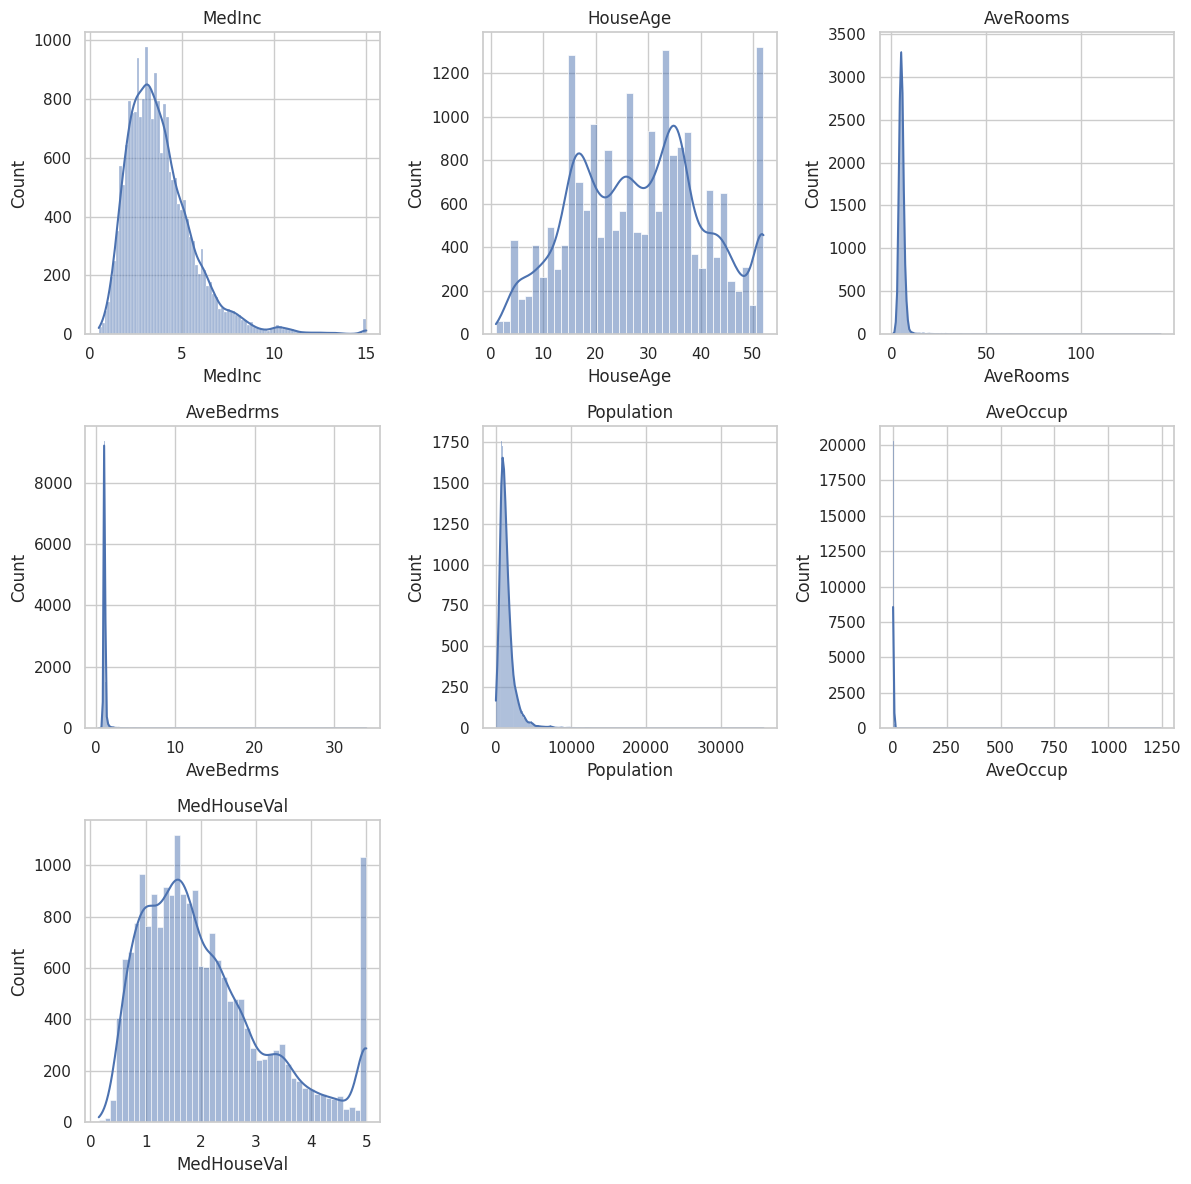

In [12]:
# Phase 2.2 – Marginal distributions (histograms with KDE, excluding coordinates)

num_cols = [col for col in df.columns if col not in ["Latitude", "Longitude"]]

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

# Hide any unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Phase 2.3 (zoomed) – Scatterplots in typical ranges

The previous scatterplots include a few extreme values for `AveRooms` and `AveOccup` that stretch the x-axis and make it hard to see patterns for typical tracts. For visualization only, we zoom in on a central range (2–10 rooms, 0.5–8 occupants) to better understand the relationships in the bulk of the data, while still keeping the full dataset unchanged for later modeling.

In [ ]:
# Phase 2.3 (zoomed) – Scatterplots within typical ranges for AveRooms and AveOccup

# Define a zoomed-in subset for visualization only
zoom_mask = (
    (df["AveRooms"] >= 2) & (df["AveRooms"] <= 10) &
    (df["AveOccup"] >= 0.5) & (df["AveOccup"] <= 8)
)

df_zoom = df[zoom_mask].copy()

zoom_predictors = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, zoom_predictors):
    sns.scatterplot(data=df_zoom, x=col, y="MedHouseVal", alpha=0.3, ax=ax)
    ax.set_title(f"MedHouseVal vs {col} (zoomed)")

plt.tight_layout()
plt.show()

### Dataset summary and Histograms explanations

**Median income (`MedInc`)** ranges from about 0.5 to 15 (in $10k units), with a mean around 3.87. The long upper tail relative to the quartiles indicates strong right-skewness: most block groups sit in the lower-middle income range, with a small number of very high-income areas. This suggests that a log or other nonlinear transform of income may be helpful in later models.

**House age (`HouseAge`)** spans from 1 to 52 years, with a mean near 28.6. The distribution is not perfectly unimodal and likely reflects different construction eras, so a strictly linear effect of age may be too simplistic.

**Average rooms (`AveRooms`)** has a mean of about 5.43 rooms per household, but ranges from ~0.85 to over 140. The extremely large maximum and very small minimum create extreme right skewness and hint at possible outliers or tracts with very unusual household structures (e.g. very few households or data artifacts). These extreme values should be investigated, and we may consider capping or transforming this feature.

**Population** ranges from 3 to over 35,000, with a mean around 1,425. The upper tail is much heavier than the lower tail, again indicating strong right-skewness driven by a few very dense tracts. Models that are sensitive to scale may benefit from transformations or robust approaches here.

**Median house value (`MedHouseVal`)** ranges from about 0.15 to 5.0 (in $100k units), with a mean near 2.07 and a right-skewed distribution. The upper bound at 5.0 suggests censoring of the highest-value tracts, which compresses very expensive areas into a single top category and can affect coefficient estimates.

The correlation matrix and correlations with `MedHouseVal` identify the predictors most strongly associated with the target and reveal that some predictors, such as `AveRooms` and `AveBedrms`, are highly correlated with each other. This redundancy can cause multicollinearity in linear models and motivates the use of regularization or PCA later to stabilize coefficient estimates and reduce effective dimensionality.

Overall, the strong skewness and presence of outliers in several key predictors motivate:
 -  targeted transformations (e.g. logs or polynomial terms), 
 -  cautious outlier handling, and 
 -  modeling choices that are robust to multicollinearity. 
 
These observations will directly inform the feature engineering and model specification decisions in Phase 3.

### Conditional relationships: `MedHouseVal` vs key predictors

Next, we look at how median house value varies with a few important predictors: median income, average rooms, occupancy, and geographic location. This helps us see whether simple linear relationships are plausible or whether curvature, saturation, or other nonlinear patterns are present.

In the scatterplots below, I focus on four predictors: `MedInc`, `AveRooms`, `HouseAge`, and `AveOccup`. 

- `MedInc` captures local purchasing power and is a natural primary driver of housing prices.
- `AveRooms` reflects typical house size/quality in a tract.
- `HouseAge` summarizes the age of the housing stock, which may affect both physical condition and neighborhood character.
- `AveOccup` measures **crowding** (average people per household), which is more interpretable than raw `Population` because it normalizes by the number of households. High occupancy can indicate overcrowding or multi-family sharing, which may put downward pressure on prices, while moderate occupancy is typical.

These variables together give a compact view of economic status, housing quality, age, and crowding, which are central to the hypothesized data-generating process for `MedHouseVal`.

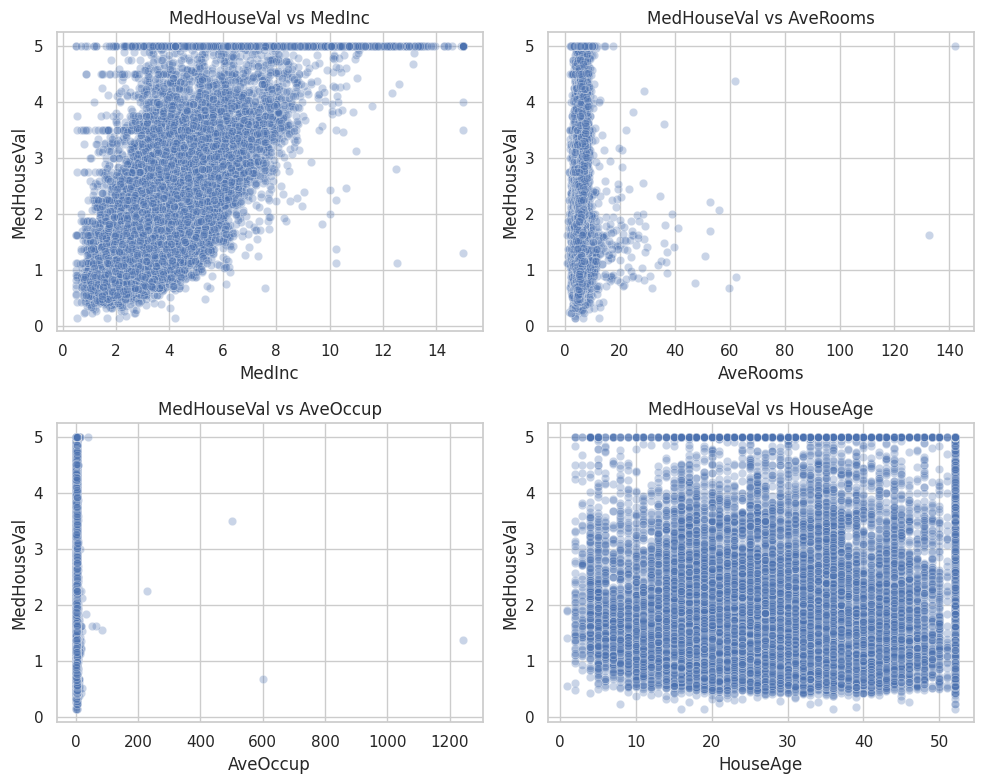

In [13]:
# Phase 2.3 – Scatterplots of MedHouseVal vs selected predictors (excluding coordinates)

key_predictors = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_predictors):
    sns.scatterplot(data=df, x=col, y="MedHouseVal", alpha=0.3, ax=ax)
    ax.set_title(f"MedHouseVal vs {col}")

plt.tight_layout()
plt.show()

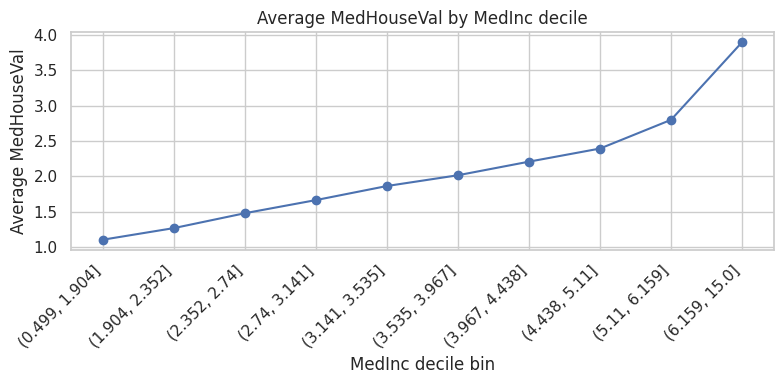

In [8]:
# Phase 2.4 – Binned relationship between MedInc and MedHouseVal

# Bin median income into quantiles and examine average house value in each bin
medinc_bins = pd.qcut(df["MedInc"], q=10)

binned = df.groupby(medinc_bins)["MedHouseVal"].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.plot(range(len(binned)), binned["MedHouseVal"], marker="o")
plt.xticks(range(len(binned)), binned["MedInc"].astype(str), rotation=45, ha="right")
plt.xlabel("MedInc decile bin")
plt.ylabel("Average MedHouseVal")
plt.title("Average MedHouseVal by MedInc decile")
plt.tight_layout()
plt.show()

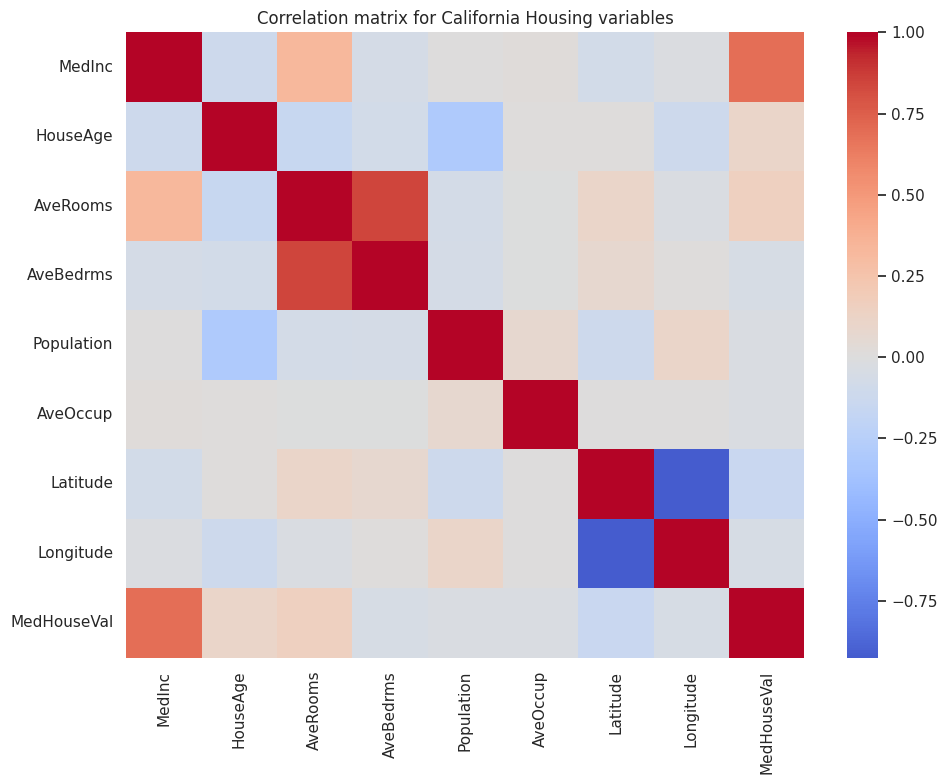

Correlations with MedHouseVal:
 MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [9]:
# Phase 2.5 – Correlation matrix and heatmap

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix for California Housing variables")
plt.tight_layout()
plt.show()

# Sort correlations with the target for a quick summary
target_corr = corr["MedHouseVal"].sort_values(ascending=False)
print("Correlations with MedHouseVal:\n", target_corr)

### Phase 2 – EDA conclusions

From the histograms and KDE plots, we can assess which variables are skewed (e.g. population and occupancy) and the overall range of each feature. Scatterplots of `MedHouseVal` against `MedInc`, `AveRooms`, and the location variables typically show strong positive associations, with some curvature for income, suggesting that a log or polynomial transform of `MedInc` may be helpful.

The correlation matrix and the printed correlations with `MedHouseVal` highlight which predictors are most strongly associated with the target, and also reveal that some predictors such as `AveRooms` and `AveBedrms` are highly correlated with each other. This redundancy can cause multicollinearity in linear models and motivates the use of regularization or PCA later to stabilize coefficient estimates and reduce effective dimensionality. These observations will directly inform the feature engineering choices in Phase 3.